<a href="https://colab.research.google.com/github/suneetchugh-dev/Deep_Learning_Workshop/blob/main/Deep_Learning_Workshop_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Program 1 : to implement an artifical neuron model using python that predicts whether a circuit is on 1 or off 0
#Step Function for Circuit
#Step Activation Function

In [ ]:
import numpy as np

def step_function(x):
  if x>=0:
    return 1
  else:
    return 0





In [ ]:
#Artificial Neuron

def neuron(inputs, weights, bias):
  weighted_sum = np.dot(inputs, weights) + bias
  output = step_function(weighted_sum)
  return weighted_sum, output


In [ ]:
X = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0],
])

# Weights and Bias configured for AND logic
weights = np.array([1, 1])
bias = -1.5

# Print Header
print("-" * 45)
print(f"{'Input1':^6} {'Input2':^8} {'WeightedSum':^12} {'Output':^8}")
print("-" * 45)

# Iterate through each sample and predict
for sample in X:
    z, y = neuron(sample, weights, bias)
    # Fixed f-string syntax and spacing
    print(f"{sample[0]:^6} {sample[1]:^8} {z:^12.2f} {y:^8}")

print("-" * 45)

---------------------------------------------
Input1  Input2  WeightedSum   Output 
---------------------------------------------
  1       1         0.50        1    
  1       0        -0.50        0    
  0       1        -0.50        0    
  0       0        -1.50        0    
---------------------------------------------


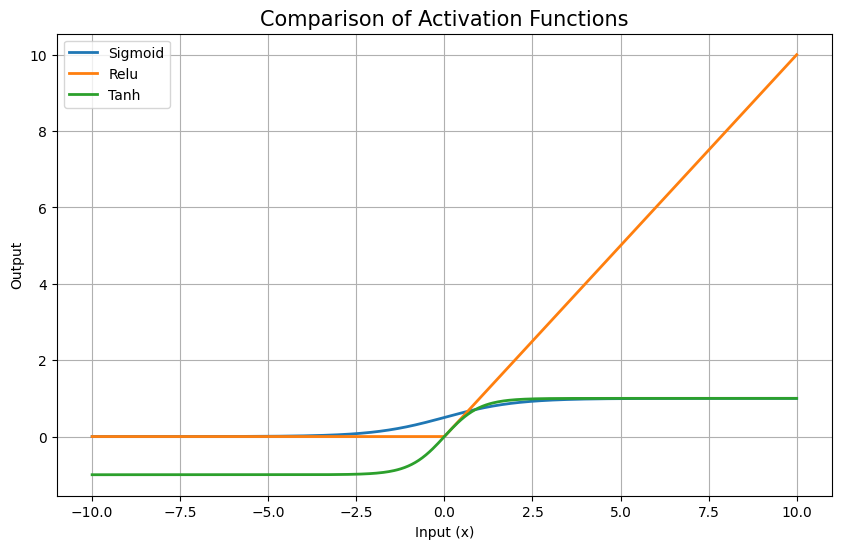

In [ ]:
#Program-2. A biomedical system needs
#nonlinear transformations for
#classification. Implement and
#compare activation functions:
#Sigmoid, ReLU, and Tanh.


import numpy as np
import matplotlib.pyplot as plt

#input values

x = np.linspace(-10,10,400)

#Activation Functions

def sigmoid(x):
  return 1/ (1+np.exp(-x))

def relu(x):
  return np.maximum(0,x)

def tanh(x):
  return np.tanh(x)

#Calculating Outputs

y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)


#Plot graph


plt.figure(figsize=(10,6))

plt.plot(x, y_sigmoid, label="Sigmoid", linewidth=2)
plt.plot(x, y_relu, label="Relu", linewidth=2)
plt.plot(x, y_tanh, label="Tanh", linewidth=2)



plt.title("Comparison of Activation Functions", fontsize=15)

plt.xlabel("Input (x)")
plt.ylabel("Output")


plt.grid(True)

plt.legend()

plt.show()




In [ ]:
#3. A digital automation system
#must perform logical operations.
#Design a Perceptron model to
#simulate AND and OR gates.

import numpy as np

# Step activation function
def step_function(x):
    return 1 if x >= 0 else 0

# Perceptron function
def perceptron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights) + bias
    output = step_function(weighted_sum)
    return weighted_sum, output  # Return both weighted sum and output

# Input data (all combinations of 2-bit binary inputs)
X = np.array([
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 0],
])

# ============= AND Gate =============
print("=" * 50)
print("AND GATE")
print("=" * 50)

weights_and = np.array([1, 1])
bias_and = -1.5

print("Input1  Input2  Weighted Sum  Output")
for sample in X:
    z, y = perceptron(sample, weights_and, bias_and)
    print(f"{sample[0]: ^7} {sample[1]: ^8} {z: ^14.2f} {y: ^7}")

# ============= OR Gate =============
print("\n" + "=" * 50)
print("OR GATE")
print("=" * 50)

weights_or = np.array([1, 1])
bias_or = -0.5

print("Input1  Input2  Weighted Sum  Output")
for sample in X:
    z, y = perceptron(sample, weights_or, bias_or)
    print(f"{sample[0]: ^7} {sample[1]: ^8} {z: ^14.2f} {y: ^7}")

AND GATE
Input1  Input2  Weighted Sum  Output
   1       1          0.50         1   
   1       0         -0.50         0   
   0       1         -0.50         0   
   0       0         -1.50         0   

OR GATE
Input1  Input2  Weighted Sum  Output
   1       1          1.50         1   
   1       0          0.50         1   
   0       1          0.50         1   
   0       0         -0.50         0   


In [ ]:
# 4.A training system must ensure
# learning convergence. Implement
# the Perceptron learning rule and
# verify convergence


import numpy as np

#Training Datatset (AND GATE)
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y = np.array([0,0,0,1])

#Parameters
learning_rate = 0.1
epochs = 20

#Initial weight and bias
weight = np.zeros(2)
bias = 0

#step activation function
def step_function(x):
    return 1 if x>=0 else 0

#Training
print("="*70)
for epoch in range(epochs):
    total_error = 0
    print(f"\nEpoch {epoch+1}")

    epoch_updated = False

    for i in range(len(X)):
        net = np.dot(X[i], weight) + bias
        prediction = step_function(net)
        error = y[i] - prediction

        total_error += abs(error)

        if error != 0:
            epoch_updated = True
            weight = weight + learning_rate * error * X[i]

            bias = bias + learning_rate * error

        print(f"Input= {X[i]} Target={y[i]} Predicted={prediction} Error={error}")

    print(f"Weights = {weight}, Bias = {bias}")

    if total_error == 0:
        print("\n" + "="*70)
        print(f"Convergence achieved at Epoch {epoch+1}! No errors found.")
        print(f"Final Weights: {weight}, Final Bias: {bias}")
        break
else:
    print("\nMaximum epochs reached without full convergence (though AND is linearly separable).")

# Final Verification
print("\n" + "="*70)
print("Final Model Verification:")
for i in range(len(X)):
    net = np.dot(X[i], weight) + bias
    pred = step_function(net)
    print(f"Input: {X[i]} | Target: {y[i]} | Predicted: {pred}")


Epoch 1
Input= [0 0] Target=0 Predicted=1 Error=-1
Input= [0 1] Target=0 Predicted=0 Error=0
Input= [1 0] Target=0 Predicted=0 Error=0
Input= [1 1] Target=1 Predicted=0 Error=1
Weights = [0.1 0.1], Bias = 0.0

Epoch 2
Input= [0 0] Target=0 Predicted=1 Error=-1
Input= [0 1] Target=0 Predicted=1 Error=-1
Input= [1 0] Target=0 Predicted=0 Error=0
Input= [1 1] Target=1 Predicted=0 Error=1
Weights = [0.2 0.1], Bias = -0.1

Epoch 3
Input= [0 0] Target=0 Predicted=0 Error=0
Input= [0 1] Target=0 Predicted=1 Error=-1
Input= [1 0] Target=0 Predicted=1 Error=-1
Input= [1 1] Target=1 Predicted=0 Error=1
Weights = [0.2 0.1], Bias = -0.20000000000000004

Epoch 4
Input= [0 0] Target=0 Predicted=0 Error=0
Input= [0 1] Target=0 Predicted=0 Error=0
Input= [1 0] Target=0 Predicted=0 Error=0
Input= [1 1] Target=1 Predicted=1 Error=0
Weights = [0.2 0.1], Bias = -0.20000000000000004

Convergence achieved at Epoch 4! No errors found.
Final Weights: [0.2 0.1], Final Bias: -0.20000000000000004

Final Model V

In [ ]:
# 5. A neural system adapts based on
# signal correlation. Implement
# Hebbian Learning rule.

#//Code =>


import numpy as np

#Input Patterns

X = np.array([
    [1,1],
    [1,-1],
    [-1,1],
    [-1,-1],
])



#Desired

Y = np.array([1,-1,-1,1])

#initialise weights

weights =- np.zeros(2)
bias = 0

print("Initial Weight:", weights)
print("Intial Bias", bias)

#Hebian Learning
for i in range(len(X)):
  weights = weights + X[i] * Y[i]

  bias = bias + Y[i]

  print("\nPattern", i+1)
  print("Input:", X[i])
  print("Target:", Y[i])
  print("Updated Weights:", weights)
  print("Updated Bias:", bias)

print("\n===========================")
print("Final Weights =", weights)
print("Final Bias =", bias)





Initial Weight: [-0. -0.]
Intial Bias 0

Pattern 1
Input: [1 1]
Target: 1
Updated Weights: [1. 1.]
Updated Bias: 1

Pattern 2
Input: [ 1 -1]
Target: -1
Updated Weights: [0. 2.]
Updated Bias: 0

Pattern 3
Input: [-1  1]
Target: -1
Updated Weights: [1. 1.]
Updated Bias: -1

Pattern 4
Input: [-1 -1]
Target: 1
Updated Weights: [0. 0.]
Updated Bias: 0

Final Weights = [0. 0.]
Final Bias = 0


In [ ]:
# 6. An AI model requires

# optimization to minimize error.

# Implement Gradient Descent and

# Delta Rule.



import numpy as np
import matplotlib.pyplot as plt

#Training Data

X = np.array([1,2,3,4,5], dtype=float)
T = np.array([2,4,6,8,10], dtype=float)


#Initialise Parameters

weight = 0.0
bias = 0.0


learning_rate = 0.01
epochs = 20

mse_history = []

print("Initial Weight =", weight)
print("Initial Bias =", bias)

for epoch in range(epochs):

  total_error = 0

  for x, t in zip(X,T):

    #Forward Pass

    y= weight * x + bias


    #Error
    error = t-y

    #delta Rule
    weight = weight + learning_rate * error * x
    bias = bias + learning_rate * error
    total_error += error**2

    mse = total_error / len(X)

    mse_history.append(mse)


  print("\nTraining Completed")
  print("-----------------------------------")
  print("Final Weight :", round(weight,4))
  print("Final Bias :", round(bias,4))










Initial Weight = 0.0
Initial Bias = 0.0

Training Completed
-----------------------------------
Final Weight : 0.8962
Final Bias : 0.2551

Training Completed
-----------------------------------
Final Weight : 1.3621
Final Bias : 0.3853

Training Completed
-----------------------------------
Final Weight : 1.6045
Final Bias : 0.4507

Training Completed
-----------------------------------
Final Weight : 1.7309
Final Bias : 0.4825

Training Completed
-----------------------------------
Final Weight : 1.7971
Final Bias : 0.4968

Training Completed
-----------------------------------
Final Weight : 1.832
Final Bias : 0.5021

Training Completed
-----------------------------------
Final Weight : 1.8507
Final Bias : 0.5027

Training Completed
-----------------------------------
Final Weight : 1.8609
Final Bias : 0.5009

Training Completed
-----------------------------------
Final Weight : 1.8668
Final Bias : 0.4979

Training Completed
-----------------------------------
Final Weight : 1.8704
F

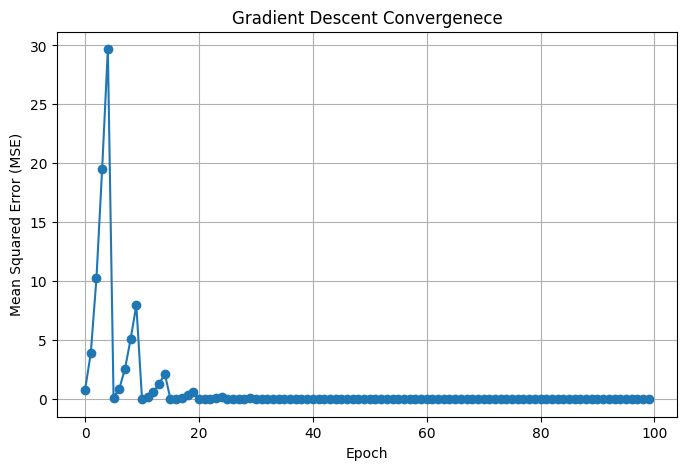

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(mse_history, marker='o')
plt.title("Gradient Descent Convergenece")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import os

df = pd.read_csv("german_credit_data.csv")
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,0


In [ ]:
df.info()


print("\nDatatset Shape:", df.shape)

print("\nColumns:")

print(df.columns)

print("\nFirst 10 Records")

display(df.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 86.1+ KB

Datatset Shape: (1000, 11)

Columns:
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

First 10 Records


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,0
5,5,35,male,1,free,NaN,NaN,9055,36,education,1
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,1
7,7,35,male,3,rent,little,moderate,6948,36,car,1
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,1
9,9,28,male,3,own,little,moderate,5234,30,car,0


In [ ]:
#Show Custom Categories

print(df["Risk"].value_counts())

Risk
1    700
0    300
Name: count, dtype: int64


In [ ]:
df.fillna("Unknown", inplace=True)


In [ ]:
#Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in df.columns:
  if df[col].dtype == "object":
    df[col] = encoder.fit_transform(df[col])
df.head()



,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,0,1,1169,6,5,1
1,1,22,0,2,1,1,2,5951,48,5,0
2,2,49,1,1,1,1,0,2096,12,3,1
3,3,45,1,2,0,1,1,7882,42,4,1
4,4,53,1,2,0,1,1,4870,24,1,0


In [ ]:
#feature and Target

X = df.drop("Risk", axis=1)

y = df["Risk"]



In [ ]:
#Train-Test-Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples: ", len(X_train))

Training Samples:  800


In [ ]:
#feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)




In [ ]:
#Create MLP model

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes = (64,32),

    activation = "relu",

    solver = "adam",

    learning_rate_init=0.001,

    max_iter = 500,

    random_state = 42
)


mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test)

#Confusion Matrix //Performance Metrics



from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy: ", round(accuracy*100x,2),"%")

print("Precision: ", round(precision, 4))

print("Recall: ", round(recall, 4))

print("F1 Score ", round(f1,4))


print("\Classification Report: \n", classification_report(y_test, y_pred))




Accuracy:  71.5 %
Precision:  0.8029
Recall:  0.7857
F1 Score  0.7942
\Classification Report: 
               precision    recall  f1-score   support

           0       0.52      0.55      0.54        60
           1       0.80      0.79      0.79       140

    accuracy                           0.71       200
   macro avg       0.66      0.67      0.67       200
weighted avg       0.72      0.71      0.72       200



<>:32: SyntaxWarning: invalid escape sequence '\C'
<>:32: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_454/3515003386.py:32: SyntaxWarning: invalid escape sequence '\C'
  print("\Classification Report: \n", classification_report(y_test, y_pred))
